# Introduction

*House price prediction is an important application of machine learning that helps estimate the value of a property based on different features such as location, area, number of rooms, and other factors. In the real estate market, accurate price prediction is useful for buyers, sellers, and investors to make informed decisions.*

*This project focuses on building a house price prediction model using historical housing data. The model analyzes patterns and relationships between input features (like size, location, furnishingstatus and etc) and the target variable (price). By applying regression techniques, the system learns from past data and predicts the price of new houses.*

*The main objective of this model is to improve prediction accuracy and provide a reliable estimate of house prices. This not only saves time but also reduces the chances of overpricing or underpricing properties. Overall, house price prediction models play a significant role in modern real estate analysis and decision-making.*


In [1]:
#LOAD THE TOOLS
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [2]:
#LOAD DATA SET 
dt=pd.read_csv("/kaggle/input/datasets/naveedarslan/housepricrpredt/Housing (1).csv")
df=pd.DataFrame(dt)
print(df)

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [3]:
#UNDERSTANDING DATA
print(df.describe()) #this will help to understand the data distrubation 
print(df.info()) #this will help to see the data type

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------

In [4]:
#CHECK NULL VALUE 
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


> NOT FOUND ANY NULL VALUE IN ALL OVER THE DATA SET

# VISUALIZE DATA

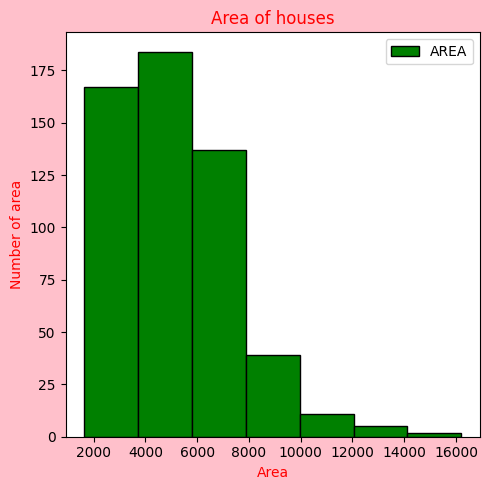

In [6]:
#VISUALIZE THE AREA OF HOUSE SPREAD
plt.figure(figsize=(5,5),facecolor='pink')  #undersatand the area of house
plt.hist(df['area'],bins=7,edgecolor='black',facecolor='green',label='AREA')
plt.xlabel('Area',color='red')
plt.ylabel('Number of area',color='red')
plt.title('Area of houses',color='red')
plt.legend()
plt.tight_layout()
plt.show()

> IN THIS GRAPH WE WILL VISUALIZE THE AREA OF HOUES
* In hist graph we will clearly seen that the area from 3800sqft to 5800sqft have the maxium number of area

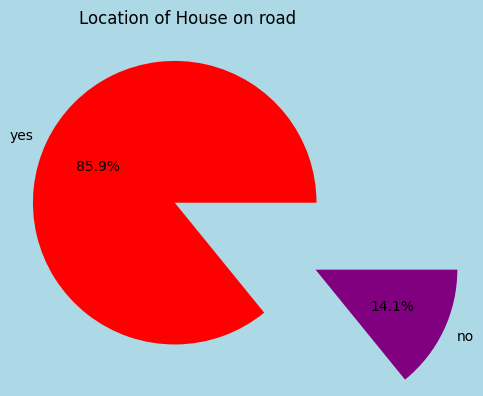

In [10]:
#location of house
MD=df['mainroad'].value_counts()
explode=(0.1,1)
plt.figure(figsize=(5,5),facecolor='LightBlue')
plt.pie(MD.values,labels=MD.index,colors=['red','purple'],autopct='%1.1f%%',explode=explode)
plt.title('Location of House on road')
plt.tight_layout()
plt.show()

> THIS PIE CHART SHOW THAT THE 85.9% HOUSE LOCATION ON ROAD AND 14.1% AWAY FROM THE ROAD

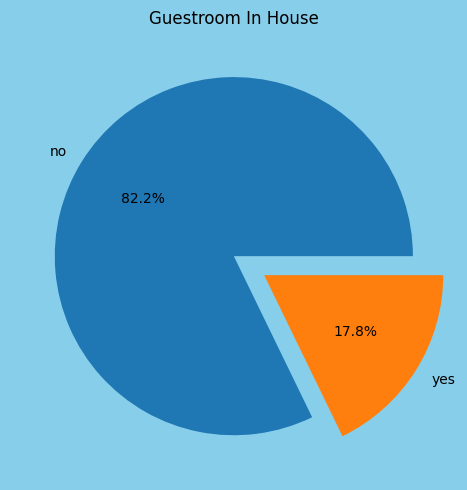

In [14]:
#GUESTROOM IN THE HOUSE RATIO
plt.figure(figsize=(5,5),facecolor='SkyBlue')
GR=df['guestroom'].value_counts()
explode=(0,0.2)
plt.pie(GR.values,labels=GR.index,autopct='%1.1f%%',explode=explode)
plt.title('Guestroom In House',color='BLACK')
plt.tight_layout()
plt.show()

> 82.2% HOUSE HAVE NOT THE GUESTROOM AND 17.8% HOUSE OWN THE GUESTROOM

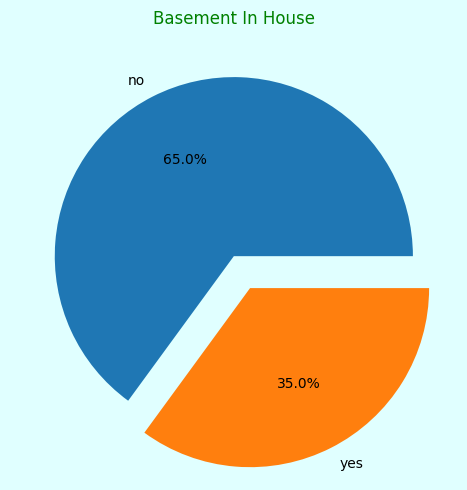

In [15]:
#HOUSE OWN BASEMENT  OR NOT
plt.figure(figsize=(5,5),facecolor='LightCyan')
GR=df['basement'].value_counts()
explode=(0,0.2)
plt.pie(GR.values,labels=GR.index,autopct='%1.1f%%',explode=explode)
plt.title('Basement In House',color='green')
plt.tight_layout()
plt.show()


> 65% HOUSES HAVE NOT THE BASEMENT ND ONLY 35% HOUSES OWN THE BASEMENT

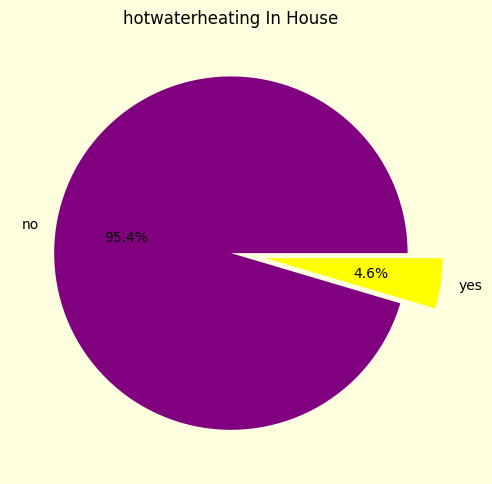

In [19]:
#HWH in house
plt.figure(figsize=(5,5),facecolor='LightYellow')
GR=df['hotwaterheating'].value_counts()
explode=(0,0.2)
plt.pie(GR.values,labels=GR.index,colors=['Purple','yellow'],autopct='%1.1f%%',explode=explode)
plt.title('hotwaterheating In House',color='BLACK')
plt.tight_layout()
plt.show()

> 95.4% HOUSES HAVE NITBTHE HOT WATERHEATING SYSTYEM ONLY 4.6% HOUSES OWN THIS SYSATEM

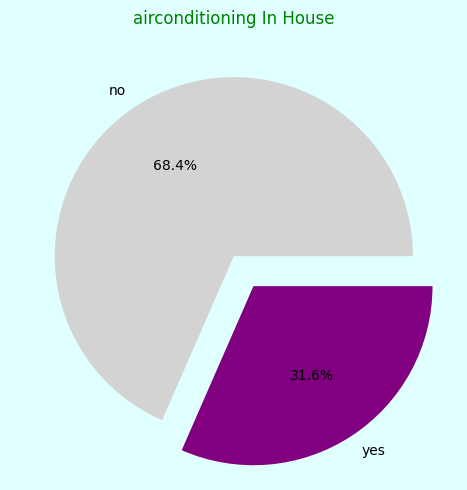

In [24]:
plt.figure(figsize=(5,5),facecolor='LightCyan')
GR=df['airconditioning'].value_counts()
explode=(0,0.2)
plt.pie(GR.values,labels=GR.index,colors=['LightGray','purple'],autopct='%1.1f%%',explode=explode)
plt.title('airconditioning In House',color='green')
plt.tight_layout()
plt.show()



> IN 68.4% HOUSE THE AIRCONDITIONQING SYSTEM HAVE NOT ONLY IN 31.6% HOUSE OWN YHIS SYSTEM

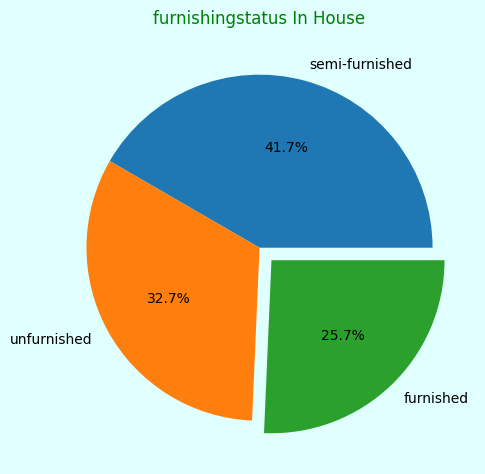

In [25]:
#FS of house
plt.figure(figsize=(5,5),facecolor='LightCyan')
GR=df['furnishingstatus'].value_counts()
explode=(0,0,0.1)
plt.pie(GR.values,labels=GR.index,autopct='%1.1f%%',explode=explode)
plt.title('furnishingstatus In House',color='green')
plt.tight_layout()
plt.show()

> IN THIS PIE GRAPH WE SEE THAT THE 41.7% IS SEMI-FURNISHED HIUSES,32.7% IS UNFURNISHED HOUSES AND 25.7% HAVE FURNISHED HOUSES

# CHEACKING OUTLIERS

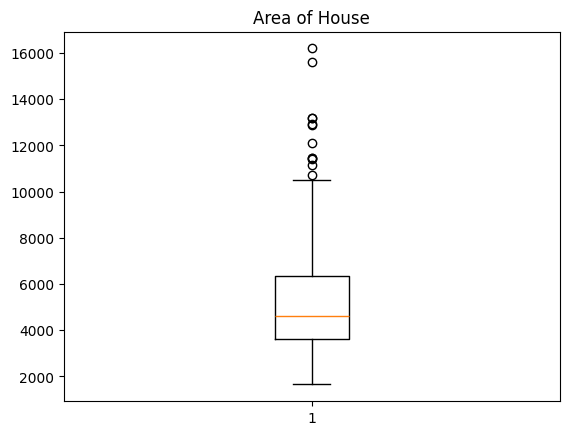

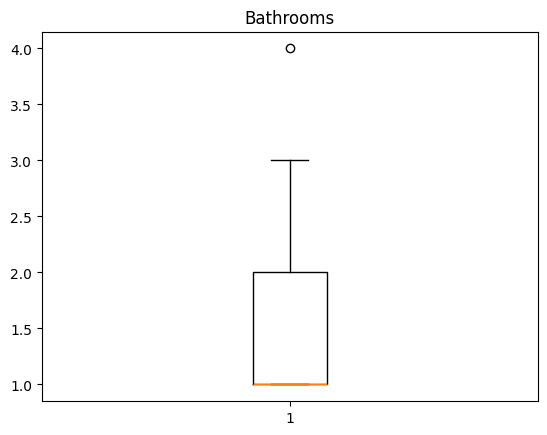

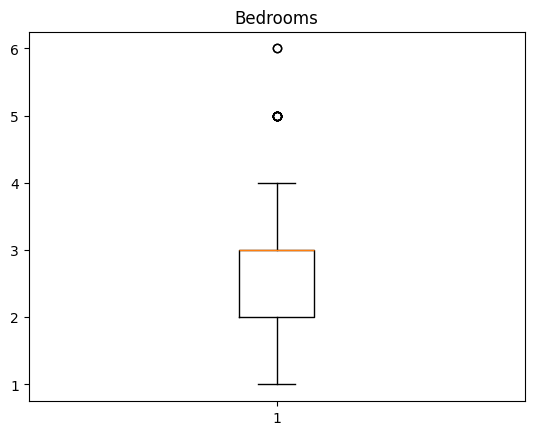

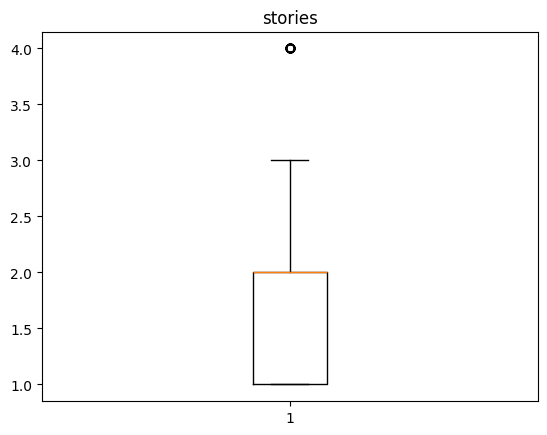

In [27]:
#CHECKING OUTLIER
plt.boxplot(df['area'])  # some outlier
plt.title("Area of House")
plt.show()

plt.boxplot(df['bathrooms'])  # one  outlier
plt.title("Bathrooms")
plt.show()

plt.boxplot(df['bedrooms'])  # two outlier
plt.title("Bedrooms")
plt.show()

plt.boxplot(df['stories'])  # one outlier
plt.title('stories')
plt.show()

> in our data set we find the outliers,so we need to scale the data

# Encoding the Catogrical Data

In [3]:
# ecoding data useing one hote ecodeing
new_df=pd.get_dummies(df,columns=['mainroad' ,'guestroom' ,'basement','hotwaterheating' ,'airconditioning','prefarea','furnishingstatus']) #FOR ECODING THE DATA WE USE GET-DUMMIES FUNCTION WHICH WILL CONVERT THE CATOGRICAL DATA INTO BINARY FORM
print(new_df)

        price  area  bedrooms  bathrooms  stories  parking  mainroad_no  \
0    13300000  7420         4          2        3        2        False   
1    12250000  8960         4          4        4        3        False   
2    12250000  9960         3          2        2        2        False   
3    12215000  7500         4          2        2        3        False   
4    11410000  7420         4          1        2        2        False   
..        ...   ...       ...        ...      ...      ...          ...   
540   1820000  3000         2          1        1        2        False   
541   1767150  2400         3          1        1        0         True   
542   1750000  3620         2          1        1        0        False   
543   1750000  2910         3          1        1        0         True   
544   1750000  3850         3          1        2        0        False   

     mainroad_yes  guestroom_no  guestroom_yes  ...  basement_yes  \
0            True          Tru

# Feature Scaling

In [4]:
#apply Standard Scaler to handle outlier
from sklearn.preprocessing import StandardScaler
STD=StandardScaler()
targ=new_df.drop(columns=['price'])
STR=new_df['price']
APL=STD.fit_transform(targ)
df2=pd.DataFrame(APL,columns=(targ.columns))
df2['price']=STR.values
print(df2)

         area  bedrooms  bathrooms   stories   parking  mainroad_no  \
0    1.046726  1.403419   1.421812  1.378217  1.517692    -0.405623   
1    1.757010  1.403419   5.405809  2.532024  2.679409    -0.405623   
2    2.218232  0.047278   1.421812  0.224410  1.517692    -0.405623   
3    1.083624  1.403419   1.421812  0.224410  2.679409    -0.405623   
4    1.046726  1.403419  -0.570187  0.224410  1.517692    -0.405623   
..        ...       ...        ...       ...       ...          ...   
540 -0.991879 -1.308863  -0.570187 -0.929397  1.517692    -0.405623   
541 -1.268613  0.047278  -0.570187 -0.929397 -0.805741     2.465344   
542 -0.705921 -1.308863  -0.570187 -0.929397 -0.805741    -0.405623   
543 -1.033389  0.047278  -0.570187 -0.929397 -0.805741     2.465344   
544 -0.599839  0.047278  -0.570187  0.224410 -0.805741    -0.405623   

     mainroad_yes  guestroom_no  guestroom_yes  basement_no  ...  \
0        0.405623      0.465315      -0.465315     0.734539  ...   
1        0.

In [14]:
#split data
X=df2.drop(columns=['price'])
Y=df2['price']


# TRAIN AND TEST THE MODEL

In [16]:
#APPLY POLYNOMIAL FEATURE TO GET THE BEST FIT LINE AND THE PREDICTION
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=4) 
x_poly=poly.fit_transform(X)


In [17]:
#LOAD THE MODEL
model=LinearRegression()

In [18]:
#TRAIN THE MODEL
model.fit(x_poly,Y)   #AT THIS POINT THE MODEL READ THE DATA
prediction=model.predict(x_poly)  # AND AT THIS POINT THE MODEL WILL GIVE THE PREDICTION
print(prediction)

[13299999.99999977 12249999.99999905 12250000.00000008 12215000.00000055
 11409999.99999987 10850000.00000011 10149999.99999883 10149999.99999665
  9870000.00000014  9799999.99999983  9800000.00000022  9680999.99999938
  9309999.99999986  9240000.00000039  9239999.99999978  9099999.99999985
  9099999.99999989  8959999.99999968  8889999.99999992  8854999.99999986
  8750000.00000074  8679999.99999957  8644999.99999993  8644999.99999981
  8574999.99999972  8540000.          8462999.99999986  8400000.
  8399999.99999909  8399999.99999984  8400000.          8399999.99999972
  8294999.99999978  8189999.99999981  8119999.99999982  8080939.99999992
  8043000.0000005   7979999.99999961  7962499.99999985  7909999.99999982
  7874999.9999999   7839999.99999993  7700000.00000005  7699999.99999966
  7559999.99999995  7559999.99999991  7524999.99999992  7490000.00000024
  7454999.9999999   7419999.99999996  7419999.99999997  7420000.00000001
  7349999.99999954  7349999.99999983  7349999.99999988  735

In [19]:
#MODEL EVALUTION
R2=r2_score(Y,prediction)
ABE=mean_absolute_error(Y,prediction)
MSE=mean_squared_error(Y,prediction)
RMSE=np.sqrt(MSE)
print("Model Performance = ",R2)
print(ABE)
print(MSE)
print(RMSE)



Model Performance =  0.9932348868709651
45201.853936035084
23624620742.413803
153703.0277594225


# Best Fit Line Graph

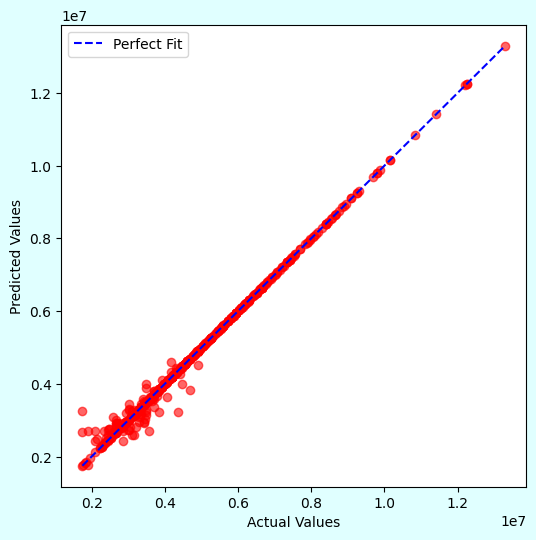

In [25]:
#actual vs prediction 
plt.figure(facecolor='LightCyan',figsize=(6,6))
plt.scatter(Y,prediction,color='red',alpha=0.6,marker='o')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],color='blue', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

